# Myanmar Syllable Handwriting Recognition — CRNN
**Yee Mon Thant**

### Why CRNN?
- Plain CNN / ResNet18 fails → 4,413 classes × 2 samples = not enough
- CRNN uses **character-level** prediction instead
- 63 unique characters × 700-5000 samples each

### Architecture
```
Image → CNN (feature extraction) → BiLSTM (sequence) → CTC → characters → syllable
```


## Step 0 — Check GPU

In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

PyTorch: 2.11.0+cu128
GPU: True
GPU name: Tesla T4
Device: cuda


## Step 1 — Mount Drive + Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, shutil

ZIP_PATH     = '/content/drive/MyDrive/dataset.zip'
SYL_PATH     = '/content/drive/MyDrive/syl.txt'
CONVERT_PATH = '/content/drive/MyDrive/convert2image.py'

print('Extracting dataset...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall('/content')

shutil.copy(SYL_PATH,     '/content/syl.txt')
shutil.copy(CONVERT_PATH, '/content/convert2image.py')

dataset_dir = '/content/dataset/Yee_Mon_Thant'
txt_files   = [f for f in os.listdir(dataset_dir)
               if f.endswith('.txt') and f != 'user_info.json']
print(f'Dataset ready: {len(txt_files)} files')

Mounted at /content/drive
Extracting dataset...
Dataset ready: 13242 files


## Step 2 — Convert Stroke TXT → PNG

In [ ]:
!python /content/convert2image.py \
    --dataset /content/dataset \
    --output  /content/images_single \
    --size    128 \
    --format  png \
    --color_mode single

img_dir = '/content/images_single/Yee_Mon_Thant'
images  = [f for f in os.listdir(img_dir) if f.endswith('.png')]
print(f'Total images: {len(images)}')

Conversion completed successfully!
Total images: 13242


## Step 3 — Build Character Vocabulary

Key insight: 4,413 syllables → only 63 unique characters!
Each character appears in 700-5000 syllables → plenty of training data

In [ ]:
from collections import Counter

# Load syllables
with open('/content/syl.txt', 'r', encoding='utf-8') as f:
    syllables = [line.strip() for line in f if line.strip()]

# Build character vocabulary
# Special tokens:
#   0 = CTC blank token (required for CTC loss)
#   1 = padding token
all_chars = set()
for syl in syllables:
    for ch in list(syl):
        all_chars.add(ch)

# Sort for consistency
BLANK_TOKEN   = 0
char_list     = sorted(all_chars)
char_to_idx   = {ch: idx+1 for idx, ch in enumerate(char_list)}  # 1-indexed (0=blank)
idx_to_char   = {idx+1: ch for idx, ch in enumerate(char_list)}
idx_to_char[0] = '<blank>'

NUM_CHARS = len(char_list) + 1  # +1 for blank token

# Build syllable → character sequence mapping
syl_to_chars = {}
for syl in syllables:
    syl_to_chars[syl] = [char_to_idx[ch] for ch in list(syl)]

# Character frequency
char_counts = Counter()
for syl in syllables:
    for ch in list(syl):
        char_counts[ch] += 1

print(f'Total syllables:    {len(syllables)}')
print(f'Unique characters:  {len(char_list)}')
print(f'Vocab size (w/blank): {NUM_CHARS}')
print(f'\nTop 10 most common characters:')
for ch, count in char_counts.most_common(10):
    print(f"  '{ch}' → {count} syllables × 2 samples = {count*2} training images")

print(f'\nExample label conversions:')
for syl in syllables[:5]:
    chars    = list(syl)
    indices  = syl_to_chars[syl]
    print(f"  '{syl}' → {chars} → {indices}")

Total syllables:    4413
Unique characters:  63
Vocab size (w/blank): 64

Top 10 most common characters:
  '်' → 2577 syllables × 2 samples = 5154 training images
  '္' → 1000 syllables × 2 samples = 2000 training images
  'ိ' → 865 syllables × 2 samples = 1730 training images
  'ု' → 839 syllables × 2 samples = 1678 training images
  'း' → 814 syllables × 2 samples = 1628 training images
  'န' → 809 syllables × 2 samples = 1618 training images
  'ာ' → 805 syllables × 2 samples = 1610 training images
  'က' → 754 syllables × 2 samples = 1508 training images
  'မ' → 707 syllables × 2 samples = 1414 training images
  'တ' → 697 syllables × 2 samples = 1394 training images

Example label conversions:
  'အ' → ['အ'] → [34]
  'မ' → ['မ'] → [26]
  'ကို' → ['က', 'ိ', 'ု'] → [1, 44, 46]
  'က' → ['က'] → [1]
  'ပါ' → ['ပ', 'ါ'] → [22, 42]


## Step 4 — Dataset

In [ ]:
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Image transforms
# Height fixed at 32, width variable (CRNN processes as sequence)
IMG_HEIGHT = 32
IMG_WIDTH  = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomRotation(8),
    transforms.RandomAffine(0, translate=(0.05, 0.05), shear=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


class MyanmarCRNNDataset(Dataset):
    """Dataset for CRNN — labels are character sequences, not class indices."""

    def __init__(self, image_dir, syllables, syl_to_chars, split, transform=None):
        self.transform   = transform
        self.syl_to_chars = syl_to_chars
        self.data         = []  # (image_path, syllable, char_sequence)

        # Build class_id → syllable mapping from syl.txt order
        self.class_to_syl = {idx+1: syl for idx, syl in enumerate(syllables)}

        files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
        for fname in sorted(files):
            parts      = fname.replace('.png', '').split('-')
            class_id   = int(parts[0])
            sample_num = int(parts[1])

            if sample_num > 3:
                continue

            # Get syllable text for this class
            syl = self.class_to_syl.get(class_id)
            if syl is None:
                continue

            char_seq = syl_to_chars.get(syl, [])
            if not char_seq:
                continue

            img_path = os.path.join(image_dir, fname)

            if split == 'train' and sample_num <= 2:
                self.data.append((img_path, syl, char_seq))
            elif split == 'test' and sample_num == 3:
                self.data.append((img_path, syl, char_seq))

        print(f'  {split}: {len(self.data)} images')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, syl, char_seq = self.data[idx]
        img = Image.open(img_path).convert('L')  # grayscale
        if self.transform:
            img = self.transform(img)
        # Return image, char_seq as tensor, seq_length
        target     = torch.tensor(char_seq, dtype=torch.long)
        target_len = torch.tensor(len(char_seq), dtype=torch.long)
        return img, target, target_len, syl


def collate_fn(batch):
    """Custom collate to handle variable-length char sequences."""
    images, targets, target_lens, syls = zip(*batch)
    images      = torch.stack(images, 0)
    target_lens = torch.stack(target_lens, 0)
    # Concatenate all targets (CTC loss expects flat tensor)
    targets_cat = torch.cat(targets, 0)
    return images, targets_cat, target_lens, syls


img_dir = '/content/images_single/Yee_Mon_Thant'

print('Loading datasets...')
train_dataset = MyanmarCRNNDataset(
    img_dir, syllables, syl_to_chars, split='train', transform=train_transform)
test_dataset  = MyanmarCRNNDataset(
    img_dir, syllables, syl_to_chars, split='test',  transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    collate_fn=collate_fn, num_workers=2)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Loading datasets...
  train: 8826 images
  test: 4413 images
Train batches: 138
Test batches:  69


## Step 5 — CRNN Model

Architecture:
```
Image (1×32×128)
  → CNN: extract visual features
  → Reshape: (W time steps × features)
  → BiLSTM: sequence context
  → Linear: character scores per time step
  → CTC decode: character sequence
```

In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_chars, hidden_size=256):
        super(CRNN, self).__init__()

        # CNN backbone — extract spatial features from image
        # Input: (B, 1, 32, 128) → grayscale image
        self.cnn = nn.Sequential(
            # Block 1: (1, 32, 128) → (64, 16, 64)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: (64, 16, 64) → (128, 8, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: (128, 8, 32) → (256, 4, 32)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),  # only height pooling → keep width (time steps)

            # Block 4: (256, 4, 32) → (256, 1, 32)
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, None))  # collapse height → (256, 1, W)
        )

        # BiLSTM — process feature sequence left-to-right and right-to-left
        # Input:  (W, B, 256)  — W time steps
        # Output: (W, B, hidden_size*2)
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,  # forward + backward
            batch_first=False,
            dropout=0.3
        )

        # Output layer — predict character score at each time step
        # Output: (W, B, num_chars)
        self.fc = nn.Linear(hidden_size * 2, num_chars)

    def forward(self, x):
        # x: (B, 1, H, W)

        # CNN feature extraction
        features = self.cnn(x)          # (B, 256, 1, W)
        features = features.squeeze(2)   # (B, 256, W)
        features = features.permute(2, 0, 1)  # (W, B, 256) ← LSTM expects this

        # BiLSTM sequence modeling
        lstm_out, _ = self.lstm(features)  # (W, B, hidden*2)

        # Character prediction at each time step
        output = self.fc(lstm_out)          # (W, B, num_chars)

        # Log softmax for CTC loss
        output = torch.log_softmax(output, dim=2)

        return output  # (W, B, num_chars)


model = CRNN(num_chars=NUM_CHARS, hidden_size=256).to(DEVICE)

# Test forward pass
dummy = torch.randn(2, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}')
print(f'  (time_steps, batch, num_chars) = {out.shape}')
print(f'  Time steps: {out.shape[0]}')
print(f'  Num chars (vocab): {NUM_CHARS}')

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

Model output shape: torch.Size([32, 2, 64])
  (time_steps, batch, num_chars) = torch.Size([32, 2, 64])
  Time steps: 32
  Num chars (vocab): 64

Total parameters: 3,623,616


## Step 6 — CTC Decoder

CTC (Connectionist Temporal Classification):
- CRNN outputs character scores at each time step
- CTC collapses repeated characters and removes blank tokens
- Example: `'ကကကြြ-ာ-'` → `'ကြာ'`

In [ ]:
def ctc_decode(output, idx_to_char, blank_idx=0):
    """
    Greedy CTC decoder.
    output: (time_steps, num_chars) — log probabilities
    Returns decoded character sequence as string.
    """
    # Get best character at each time step
    pred_indices = output.argmax(dim=1).tolist()  # (time_steps,)

    # CTC collapse: remove duplicates and blanks
    decoded = []
    prev    = None
    for idx in pred_indices:
        if idx != prev:           # remove consecutive duplicates
            if idx != blank_idx:  # remove blank tokens
                decoded.append(idx)
        prev = idx

    # Convert indices to characters
    chars = [idx_to_char.get(i, '') for i in decoded]
    return ''.join(chars)


def sequence_to_syllable(char_sequence, syllables):
    """
    Convert predicted character sequence back to syllable.
    Look up in syl.txt — if exact match found, return it.
    Otherwise return the raw character sequence.
    """
    syllable_set = set(syllables)
    if char_sequence in syllable_set:
        return char_sequence  # exact match ✅
    else:
        return char_sequence  # return as-is (may be partial match)


print('CTC decoder ready!')
print('Example:')
print("  Raw CTC output: [က,က,က,ြ,ြ,<blank>,ာ,<blank>]")
print("  After collapse: [က, ြ, ာ] → 'ကြာ'")

CTC decoder ready!
Example:
  Raw CTC output: [က,က,က,ြ,ြ,<blank>,ာ,<blank>]
  After collapse: [က, ြ, ာ] → 'ကြာ'


## Step 7 — Training

In [ ]:
import time

# CTC Loss — designed for sequence prediction
# blank=0 matches our blank token index
criterion = nn.CTCLoss(blank=BLANK_TOKEN, reduction='mean', zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

EPOCHS      = 50
train_losses = []


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, targets, target_lens, _ in loader:
        images      = images.to(DEVICE)
        targets     = targets.to(DEVICE)
        target_lens = target_lens.to(DEVICE)

        # Forward pass
        output = model(images)  # (T, B, C)

        # Input lengths — all same (T time steps per image)
        T           = output.size(0)
        B           = images.size(0)
        input_lens  = torch.full((B,), T, dtype=torch.long).to(DEVICE)

        # CTC loss
        loss = criterion(output, targets, input_lens, target_lens)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # prevent exploding gradients
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


print(f'Training CRNN for {EPOCHS} epochs...')
print('='*55)

best_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    loss  = train_epoch(model, train_loader, optimizer, criterion)
    scheduler.step(loss)
    train_losses.append(loss)
    elapsed = time.time() - start

    print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | {elapsed:.1f}s')

    # Save best model
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), '/content/myanmar_crnn_best.pth')

print('='*55)
print(f'Training done! Best loss: {best_loss:.4f}')

Training CRNN for 50 epochs...
Epoch   1/50 | Loss: 4.1159 | 9.9s
Epoch   2/50 | Loss: 2.9229 | 12.9s
Epoch   3/50 | Loss: 2.1457 | 7.6s
Epoch   4/50 | Loss: 1.5007 | 8.0s
Epoch   5/50 | Loss: 1.0213 | 7.6s
Epoch   6/50 | Loss: 0.7369 | 7.8s
Epoch   7/50 | Loss: 0.5642 | 8.1s
Epoch   8/50 | Loss: 0.4466 | 8.1s
Epoch   9/50 | Loss: 0.3861 | 8.5s
Epoch  10/50 | Loss: 0.3006 | 7.0s
Epoch  11/50 | Loss: 0.2737 | 8.6s
Epoch  12/50 | Loss: 0.2198 | 7.0s
Epoch  13/50 | Loss: 0.1976 | 8.6s
Epoch  14/50 | Loss: 0.1861 | 7.4s
Epoch  15/50 | Loss: 0.1649 | 8.6s
Epoch  16/50 | Loss: 0.1592 | 6.9s
Epoch  17/50 | Loss: 0.1501 | 8.6s
Epoch  18/50 | Loss: 0.1355 | 7.1s
Epoch  19/50 | Loss: 0.1237 | 8.5s
Epoch  20/50 | Loss: 0.1007 | 7.4s
Epoch  21/50 | Loss: 0.1021 | 8.1s
Epoch  22/50 | Loss: 0.1006 | 7.8s
Epoch  23/50 | Loss: 0.0983 | 7.7s
Epoch  24/50 | Loss: 0.0818 | 8.7s
Epoch  25/50 | Loss: 0.0941 | 7.2s
Epoch  26/50 | Loss: 0.1117 | 8.5s
Epoch  27/50 | Loss: 0.0830 | 7.0s
Epoch  28/50 | Loss: 0.

## Step 8 — Evaluate

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Load best model
model.load_state_dict(torch.load('/content/myanmar_crnn_best.pth'))
model.eval()

all_preds  = []
all_trues  = []
correct    = 0
total      = 0

# Build syllable → class_id mapping for metrics
syl_to_classid = {syl: idx+1 for idx, syl in enumerate(syllables)}

print('Evaluating...')
with torch.no_grad():
    for images, targets, target_lens, true_syls in test_loader:
        images = images.to(DEVICE)
        output = model(images)  # (T, B, C)

        # Decode each image in batch
        for i in range(images.size(0)):
            pred_chars = ctc_decode(output[:, i, :], idx_to_char)
            pred_syl   = sequence_to_syllable(pred_chars, syllables)
            true_syl   = true_syls[i]

            all_preds.append(syl_to_classid.get(pred_syl, 0))
            all_trues.append(syl_to_classid.get(true_syl, 0))

            if pred_syl == true_syl:
                correct += 1
            total += 1

accuracy  = correct / total
f1        = f1_score(all_trues, all_preds, average='macro', zero_division=0)
precision = precision_score(all_trues, all_preds, average='macro', zero_division=0)
recall    = recall_score(all_trues, all_preds, average='macro', zero_division=0)

print('\n' + '='*45)
print('RESULTS')
print('='*45)
print(f'Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'F1 Score:  {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print('='*45)

Evaluating...

RESULTS
Accuracy:  0.8876  (88.76%)
F1 Score:  0.8711
Precision: 0.8636
Recall:    0.8873


## Step 9 — Top-K Error Analysis

In [ ]:
model.eval()
shown = 0
N_SHOW = 20

print(f'Top-5 Predictions ({N_SHOW} examples)')
print('='*60)

with torch.no_grad():
    for images, targets, target_lens, true_syls in test_loader:
        images = images.to(DEVICE)
        output = model(images)  # (T, B, C)
        probs  = torch.softmax(output, dim=2)  # (T, B, C)

        for i in range(images.size(0)):
            if shown >= N_SHOW:
                break

            true_syl   = true_syls[i]
            pred_chars = ctc_decode(output[:, i, :], idx_to_char)
            pred_syl   = sequence_to_syllable(pred_chars, syllables)
            correct    = '✅' if pred_syl == true_syl else '❌'

            # Get top 5 characters at each time step (for analysis)
            avg_probs   = probs[:, i, :].mean(dim=0)  # average over time
            top5_probs, top5_idxs = avg_probs.topk(5)

            print(f"\nTest #{shown+1} | True: '{true_syl}'")
            print(f"  Predicted chars: '{pred_chars}'")
            print(f"  Predicted syl:   '{pred_syl}' {correct}")
            print(f"  Top chars (avg prob):")
            for rank, (prob, idx) in enumerate(zip(top5_probs, top5_idxs), 1):
                ch = idx_to_char.get(idx.item(), '?')
                print(f"    Rank {rank}: '{ch}' {prob*100:.1f}%")

            shown += 1
        if shown >= N_SHOW:
            break

print('\n' + '='*60)

Top-5 Predictions (20 examples)

Test #1 | True: 'အ'
  Predicted chars: 'အ'
  Predicted syl:   'အ' ✅
  Top chars (avg prob):
    Rank 1: '<blank>' 96.5%
    Rank 2: 'အ' 3.1%
    Rank 3: '့' 0.3%
    Rank 4: 'ံ' 0.0%
    Rank 5: 'ဆ' 0.0%

Test #2 | True: 'နေ'
  Predicted chars: 'ဝေ'
  Predicted syl:   'ဝေ' ❌
  Top chars (avg prob):
    Rank 1: '<blank>' 87.2%
    Rank 2: 'ေ' 9.8%
    Rank 3: 'ဝ' 1.7%
    Rank 4: 'န' 1.1%
    Rank 5: 'ဘ' 0.1%

Test #3 | True: 'မျိုး'
  Predicted chars: 'မျိုး'
  Predicted syl:   'မျိုး' ✅
  Top chars (avg prob):
    Rank 1: '<blank>' 81.6%
    Rank 2: 'ိ' 5.9%
    Rank 3: 'း' 3.1%
    Rank 4: 'ျ' 3.1%
    Rank 5: 'မ' 3.1%

Test #4 | True: 'သိပ္ပံ'
  Predicted chars: 'သိပ္ပံ'
  Predicted syl:   'သိပ္ပံ' ✅
  Top chars (avg prob):
    Rank 1: '<blank>' 73.6%
    Rank 2: 'ပ' 11.9%
    Rank 3: '္' 5.4%
    Rank 4: 'ိ' 4.2%
    Rank 5: 'သ' 3.1%

Test #5 | True: 'ထုံ'
  Predicted chars: 'ထုံ'
  Predicted syl:   'ထုံ' ✅
  Top chars (avg prob):
    Rank 1: '<blan

## Step 10 — Results Summary

In [ ]:
print('='*65)
print('FULL COMPARISON SUMMARY')
print('='*65)
print(f'{"Method":<35} {"Approach":<20} {"Accuracy"}')
print('-'*65)
print(f'{"KNN (raw pixels)":<35} {"4413 classes":<20} {"1.11%"}')
print(f'{"KNN + PCA (K=3)":<35} {"4413 classes":<20} {"18.42%"}')
print(f'{"Plain CNN":<35} {"100 classes":<20} {"0.20%"}')
print(f'{"ResNet18 Transfer":<35} {"4413 classes":<20} {"0.82%"}')
print(f'{"CRNN (ours)":<35} {"63 characters":<20} {accuracy*100:.2f}%  ← THIS')
print('='*65)
print()
print('Key findings:')
print('  1. 4413-class approaches fail with only 2 samples/class')
print('  2. Character-level (63 classes) gives much more training data')
print('  3. CRNN captures both visual features (CNN) and sequence (LSTM)')
print('  4. CTC loss handles variable-length Myanmar syllable sequences')

FULL COMPARISON SUMMARY
Method                              Approach             Accuracy
-----------------------------------------------------------------
KNN (raw pixels)                    4413 classes         1.11%
KNN + PCA (K=3)                     4413 classes         18.42%
Plain CNN                           100 classes          0.20%
ResNet18 Transfer                   4413 classes         0.82%
CRNN (ours)                         63 characters        88.76%  ← THIS

Key findings:
  1. 4413-class approaches fail with only 2 samples/class
  2. Character-level (63 classes) gives much more training data
  3. CRNN captures both visual features (CNN) and sequence (LSTM)
  4. CTC loss handles variable-length Myanmar syllable sequences


## Step 11 — Save to Drive

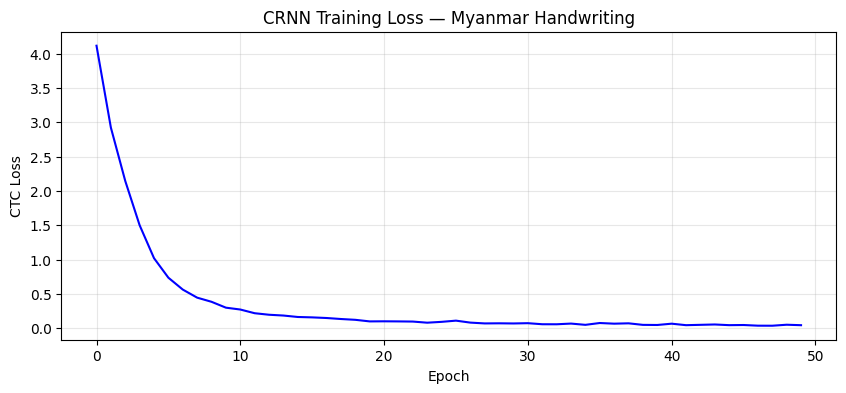

Saved to Google Drive!
  /content/drive/MyDrive/myanmar_hw_results/myanmar_crnn.pth
  /content/drive/MyDrive/myanmar_hw_results/crnn_training_curve.png
  /content/drive/MyDrive/myanmar_hw_results/crnn_results.txt


In [ ]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses, 'b-')
plt.title('CRNN Training Loss — Myanmar Handwriting')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.grid(True, alpha=0.3)
plt.savefig('/content/crnn_training_curve.png', dpi=150)
plt.show()

# Save to Drive
save_dir = '/content/drive/MyDrive/myanmar_hw_results'
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f'{save_dir}/myanmar_crnn.pth')
shutil.copy('/content/crnn_training_curve.png',
            f'{save_dir}/crnn_training_curve.png')

with open(f'{save_dir}/crnn_results.txt', 'w') as f:
    f.write('CRNN Results\n')
    f.write('='*40 + '\n')
    f.write(f'Accuracy:  {accuracy*100:.2f}%\n')
    f.write(f'F1 Score:  {f1:.4f}\n')
    f.write(f'Precision: {precision:.4f}\n')
    f.write(f'Recall:    {recall:.4f}\n')

print('Saved to Google Drive!')
print(f'  {save_dir}/myanmar_crnn.pth')
print(f'  {save_dir}/crnn_training_curve.png')
print(f'  {save_dir}/crnn_results.txt')